### Projectinformatie
**Opleiding:** Toegepaste Wiskunde & Data Science  
**Vak:** Beroepsproject 3.4  
**Begeleider:** R. Nolet  
**Datum:** 20-03-2026  

| Teamleden             | Studentnummer |
|----------------------|---------------|
| Murielle Tichelaar   | 500926485     |
| Nalini Bisessar      | 500874334     |
| Lushan Strack        | 500934278     |
| Dinand Voogt         | 500934202     |

# K-Nearest Neighbors (KNN) Model voor Churn voorspelling

We trainen een **K-Nearest Neighbors (KNN)** classifier om churn bij klanten te voorspellen.
Dit is het "model naar keuze", een classificatiemodel dat niet in de lessen behandeld is, maar wel beschikbaar is in scikit-learn.

## Modelkeuze: waarom KNN?

Voor het "model naar keuze" is gekozen voor K-Nearest Neighbors, om de volgende redenen:

**Geschiktheid voor het probleem:**  
KNN is een classificatiemodel dat goed werkt wanneer vergelijkbare klanten ook vergelijkbaar gedrag vertonen. De aanname is dat klanten met vergelijkbare gebruikspatronen (belminuten, SMS-frequentie, klachten) ook een vergelijkbare kans op churn hebben. Dit is een plausibele aanname in een telecom-context.

**Contrast met andere modellen:**  
De andere modellen in dit project (logistische regressie, beslisboom, random forest, SVM) zijn allemaal parametrische of boomgebaseerde modellen. KNN is een *instance-based* methode: het model slaat geen parameters op, maar baseert voorspellingen direct op de trainingsdata. Dit biedt een interessante vergelijking met de andere benaderingen.

**Beschikbaarheid in scikit-learn:**  
KNN is beschikbaar via `sklearn.neighbors.KNeighborsClassifier` en past naadloos in een Pipeline met preprocessing. De hyperparameters `n_neighbors` en `weights` zijn goed te tunen via GridSearchCV.

**Aandachtspunten:**  
KNN vereist dat features geschaald worden, omdat het model werkt met afstanden. Zonder schaling zouden features met grote waarden (zoals `Seconds of Use`) de afstandsberekening domineren. Daarom wordt `StandardScaler` toegepast in de preprocessing stap.

**Input:**  
- Trainingsdataset `data_train.csv` met klantkenmerken (belminuten, SMS-frequentie, gebruikspatronen)  
- Targetvariabele: `Churn` (blijft/vertrekt)

**Proces:**  
1. Data en libraries laden  
2. Feature en target variabelen definiëren  
3. Preprocessing van numerieke en categorische features  
4. Pipeline maken met preprocessing en KNN-classifier  
5. Hyperparameter optimalisatie (`n_neighbors`, `weights`) via GridSearchCV met k-fold cross-validatie  
6. Visualisatie en analyse van modelprestaties (accuracy, precision, recall, F1, ROC-AUC)  
7. Model evaluatie (confusion matrix, ROC-curve)  
8. Model opslaan (pipeline inclusief preprocessing)  
9. Beslissingsstrategie en winstanalyse (welk tarief aanbieden en verwachte winst)

**Output:**  
- Getraind KNN-model als pipeline  
- Evaluatiemetrics en visualisaties  
- Vergelijking van modelstrategie versus optimale strategie  
- Verwachte winst per maand en interpretatie van beslissingen

### 1. Data & Libraries laden

Alle benodigde Python libraries voor data-analyse, modellering en visualisatie worden geïmporteerd:
(`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`)

Twee functies voor model-evaluatie worden gedefinieerd:

- **`display_executive_model_evaluation()`** – overzicht van metrics (accuracy, precision, recall, F1) en een confusion matrix.
- **`evaluate_classification_model()`** – analyseert prestaties bij verschillende thresholds en visualiseert:
  - kansverdeling
  - performance per threshold
  - ROC-curve

De trainingsdataset `data_train.csv` wordt ingelezen met klantkenmerken.

In [33]:
import pandas as pd
import joblib
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from io import BytesIO
import base64
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier

def display_executive_model_evaluation(y_true, y_pred, class_names=None):

    # Label mapping
    unique_labels = sorted(list(set(y_true)))

    if class_names:
        if len(class_names) != len(unique_labels):
            raise ValueError("class_names moet dezelfde lengte hebben als unieke labels.")
        label_map = dict(zip(unique_labels, class_names))
        y_true = [label_map[y] for y in y_true]
        y_pred = [label_map[y] for y in y_pred]
        used_labels = class_names
    else:
        used_labels = [str(l) for l in unique_labels]

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report.get("macro avg", {})
    weighted = report.get("weighted avg", {})

    class_metrics = []
    for cls in used_labels:
        c = report.get(cls, {"precision":0,"recall":0,"f1-score":0,"support":0})
        class_metrics.append({
            "label": cls,
            "precision": c["precision"],
            "recall": c["recall"],
            "f1": c["f1-score"],
            "support": int(c["support"])
        })

    # Hover uitleg
    hover = {
        "accuracy": "Percentage correcte voorspellingen.",
        "macro": "Macro gemiddelde per klasse.",
        "weighted": "Weighted gemiddelde naar aantal observaties.",
        "precision": "Precision = TP / (TP + FP)",
        "recall": "Recall = TP / (TP + FN)",
        "f1": "F1-score = Harmonic mean van Precision en Recall.",
        "support": "Aantal observaties in deze klasse."
    }

    def info_icon(text):
        return f'<span style="font-size:10px; color:#9CA3AF; cursor:help; margin-left:4px;" title="{text}">ⓘ</span>'

    # HTML Rendering
    html = f"""
    <div style="
        font-family:'Segoe UI', Arial, sans-serif;
        max-width:850px;
        padding:40px;
        color:#111827;
        background:#FFFFFF;
        border-radius:8px;
        box-shadow: 0 8px 20px rgba(0,0,0,0.1);  
    ">

        <div style="font-size:22px; font-weight:600; margin-bottom:20px;">
            Model Performance
        </div>

        <div style="display:flex; justify-content:space-between; margin-bottom:30px;">

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Accuracy {info_icon(hover["accuracy"])}
                </div>
                <div style="font-size:36px; font-weight:600; margin-top:4px;">
                    {acc:.2%}
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Macro Average {info_icon(hover["macro"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{macro.get("precision",0):.2f}</b><br>
                    Recall: <b>{macro.get("recall",0):.2f}</b><br>
                    F1-score: <b>{macro.get("f1-score",0):.2f}</b>
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Weighted Average {info_icon(hover["weighted"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{weighted.get("precision",0):.2f}</b><br>
                    Recall: <b>{weighted.get("recall",0):.2f}</b><br>
                    F1-score: <b>{weighted.get("f1-score",0):.2f}</b>
                </div>
            </div>

        </div>

        <div style="height:1px; background:#E5E7EB; margin-bottom:25px;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:12px;">
            Per Class Performance
        </div>

        <table style="width:100%; border-collapse:collapse; font-size:13px;">
            <thead>
                <tr style="text-align:left; border-bottom:2px solid #111827;">
                    <th style="padding:8px 0;">Class</th>
                    <th>Precision</th>
                    <th>Recall</th>
                    <th>F1-score</th>
                    <th>Support</th>
                </tr>
            </thead>
            <tbody>
    """

    for c in class_metrics:
        html += f"""
            <tr style="border-bottom:1px solid #E5E7EB;">
                <td style="padding:8px 0;">{c['label']}</td>
                <td><b>{c['precision']:.2f}</b></td>
                <td><b>{c['recall']:.2f}</b></td>
                <td><b>{c['f1']:.2f}</b></td>
                <td>{c['support']}</td>
            </tr>
        """

    html += """
            </tbody>
        </table>

        <div style="height:1px; background:#E5E7EB; margin:20px 0;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:5px;">
            Confusion Matrix
        </div>

        <div id="confusion-matrix-container" style="display:flex; justify-content:center; width:100%; padding:0px 0;">
            <img src="data:image/png;base64,{confusion_matrix_img}" alt="Confusion Matrix" width="75%" />
        </div>

    </div>
    """

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    percent = cm / total * 100

    sns.set_style("white")
    plt.rcParams.update({"font.family": "DejaVu Sans"})

    fig, ax = plt.subplots(figsize=(8, 5))  # Verhoogde figuurafmetingen

    cmap = sns.light_palette("#1f4e79", as_cmap=True)

    heatmap = sns.heatmap(
        cm,
        annot=False,
        cmap=cmap,
        cbar=True,
        linewidths=0.6,
        linecolor="#ECECEC",
        square=True,
        ax=ax
    )

    threshold = cm.max() / 2

    labels_matrix = [["True Negative", "False Positive"],
                    ["False Negative", "True Positive"]]

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "#2b2b2b"

            ax.text(j + 0.5, i + 0.30,
                    labels_matrix[i][j],
                    ha='center', va='center',
                    fontsize=10,  # Kleinere lettertype
                    color=color,
                    alpha=0.9)
            
            # Groot getal in het midden
            ax.text(j + 0.5, i + 0.60,
                    f"{cm[i,j]:,}",
                    ha='center', va='center',
                    fontsize=22,  # Vergrote cijfers
                    fontweight='bold',
                    color=color)
            
            # Percentage onderin
            ax.text(j + 0.5, i + 0.85,
                    f"{percent[i,j]:.1f}%",
                    ha='center', va='center',
                    fontsize=10,  # Kleinere tekst
                    color=color,
                    alpha=0.85)

    fig.text(0.93, 0.02,
            f"Total samples: {total:,}",
            ha="right",
            va="bottom",
            fontsize=10,
            color="#6B7280")

    fig.subplots_adjust(top=0.95)

    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    ax.set_xticklabels(used_labels)
    ax.set_yticklabels(used_labels, rotation=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Sla de plot op in geheugen
    img_buffer = BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)

    # Zet het om naar base64
    confusion_matrix_img = base64.b64encode(img_buffer.read()).decode('utf-8')

    # Pas de HTML aan
    html = html.format(confusion_matrix_img=confusion_matrix_img)

    plt.close()

    # Display de volledige HTML
    display(HTML(html))

def evaluate_classification_model(y, p_pred, X, df):
    dummy = DummyClassifier(strategy="most_frequent", random_state=2026)
    dummy.fit(X, y)
    y_dummy = dummy.predict(X)
    proba_dummy = dummy.predict_proba(X)[:, 1]
    dummy_acc = accuracy_score(y, y_dummy)

    # Zet een classification report om in een rij van een dataframe
    def make_row(cr):
        return {
            'Accuracy':  cr['accuracy'],
            'Recall':    cr['1']['recall'],
            'Precision': cr['1']['precision'],
            'F1 Score':  cr['1']['f1-score']
        }

    thresholds = np.arange(0, 1, 0.01)
    plot_data = pd.DataFrame([
        make_row(classification_report(
            y, 
            p_pred > t, 
            zero_division=True, 
            output_dict=True)) for t in thresholds])
    plot_data.index = thresholds

    plt.figure(figsize=(20, 5), layout="constrained")

    # Plot 1: Distributie voorspelde kansen
    plt.subplot(1, 3, 1)
    sns.kdeplot(
        data=df,
        x=p_pred,
        hue="Churn",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5,

    )
    plt.xlim(0, 1)
    plt.title("Verdeling voorspelde kansen")
    plt.xlabel("Voorspelde kans op churn")
    plt.ylabel("Dichtheid")
    plt.grid(alpha=0.15)

    # Plot 2: Metrics vs threshold
    plt.subplot(1, 3, 2)
    sns.lineplot(data=plot_data)
    plt.axhline(dummy_acc, linestyle="--", linewidth=1.5, color="black", alpha=0.6, label="Baseline Accuracy")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.15)
    plt.title("Performance vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()

    # Plot 3: ROC curve
    ax = plt.subplot(1, 3, 3)
    roc_display = RocCurveDisplay.from_predictions(
        y,
        p_pred,
        ax=ax,
        plot_chance_level=True,
        curve_kwargs={"linewidth": 2}
    )
    plt.fill_between(roc_display.fpr, roc_display.tpr, color="#1f3b73", alpha=0.1)
    plt.title("ROC Curve")
    plt.grid(alpha=0.15)
    plt.show()

In [34]:
# Alleen train inladen
train_path = "data_train.csv"
df = pd.read_csv(train_path, sep=",", decimal=".")
df.head()

,Call Failure,Complaints,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Age,Churn
0,1,0,39,2970,29,487,11,3,30,0
1,5,0,20,1755,29,33,16,2,25,0
2,0,0,38,990,20,32,15,2,25,0
3,24,0,29,16370,242,14,93,2,25,0
4,9,0,40,4075,67,7,4,3,30,0


### 2. Feature en target variabelen definiëren

De dataset wordt opgesplitst in:
- **X**: de featurevariabelen
- **y**: de targetvariabele (Churn)

In [35]:
target = "Churn"
X = df.drop(columns=[target])
y = df[target]

X.shape, y.shape

((1995, 9), (1995,))

### 3. Data preprocessing & pipeline

Features worden verdeeld in numeriek en categorisch:

- Numeriek → `StandardScaler`  
- Categorie (Age Group) → `OneHotEncoder`  

Schaling is bij KNN **essentieel**: omdat het model werkt met afstanden tussen punten, zouden features met grote waarden (zoals `Seconds of Use`) anders een onevenredig grote invloed hebben zonder schaling.

Vervolgens wordt een pipeline gemaakt met **preprocessing** en een **KNN-classifier**, zodat alle stappen automatisch tijdens training en voorspelling worden toegepast.

In [36]:
cat_cols = ["Age Group"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

knn_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

### 4. Hyperparameteroptimalisatie

Voor KNN zijn de belangrijkste hyperparameters:

- **`n_neighbors` (k)**: het aantal buren dat meegenomen wordt in de voorspelling. Een kleine k maakt het model gevoelig voor ruis; een grote k maakt het model soepeler maar minder lokaal.
- **`weights`**: `uniform` geeft alle buren gelijk gewicht; `distance` geeft dichterbije buren meer gewicht.

We testen verschillende combinaties met **GridSearchCV** en **5-fold cross-validatie**, gescoord op **ROC-AUC**.

In [37]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20]

gridsearch_knn = GridSearchCV(
    knn_pipe,
    param_grid={
        "model__n_neighbors": k_values,
        "model__weights": ["uniform", "distance"]
    },
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

gridsearch_knn.fit(X, y)

print("Beste parameters:", gridsearch_knn.best_params_)
print("Beste AUC:", gridsearch_knn.best_score_)

Beste parameters: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Beste AUC: 0.9641071749685308


### 5. Analyse modelgedrag

Visualisatie van de gemiddelde ROC-AUC per waarde van `n_neighbors`, uitgesplitst naar `weights`.
Dit laat zien hoe de keuze van k de modelprestaties beïnvloedt en welke combinatie optimaal is.

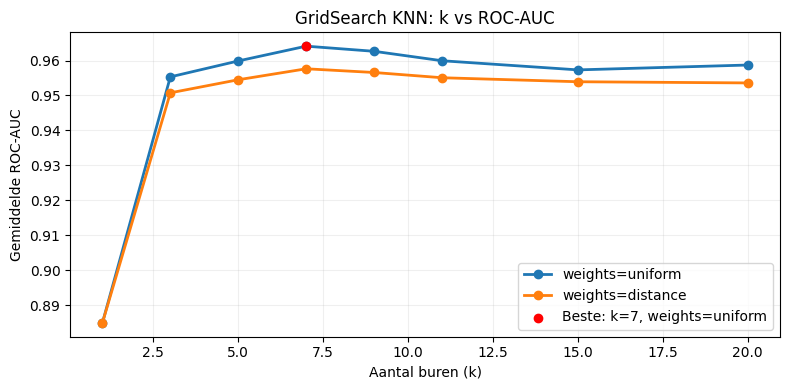

In [40]:
cv_results = pd.DataFrame(gridsearch_knn.cv_results_)

plt.figure(figsize=(8, 4))

for weight in ["uniform", "distance"]:
    subset = cv_results[cv_results["param_model__weights"] == weight]
    plt.plot(
        subset["param_model__n_neighbors"],
        subset["mean_test_score"],
        marker="o", linewidth=2, label=f"weights={weight}"
    )

best_k = gridsearch_knn.best_params_["model__n_neighbors"]
best_w = gridsearch_knn.best_params_["model__weights"]
best_score = gridsearch_knn.best_score_
plt.scatter([best_k], [best_score], color="red", zorder=5,
            label=f"Beste: k={best_k}, weights={best_w}")

plt.xlabel("Aantal buren (k)")
plt.ylabel("Gemiddelde ROC-AUC")
plt.title("GridSearch KNN: k vs ROC-AUC")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 6. Model evaluatie

Het beste model uit de grid search wordt geëvalueerd op de trainingsdata.
We bekijken:
- **Accuracy, precision, recall, F1-score** via de executive evaluatieweergave
- **Confusion matrix** voor een overzicht van correcte en incorrecte voorspellingen
- **Kansverdeling**, **performance vs threshold** en **ROC-curve**

Class,Precision,Recall,F1-score,Support
Blijft,0.97,0.98,0.97,1660
Vertrekt,0.88,0.85,0.87,335

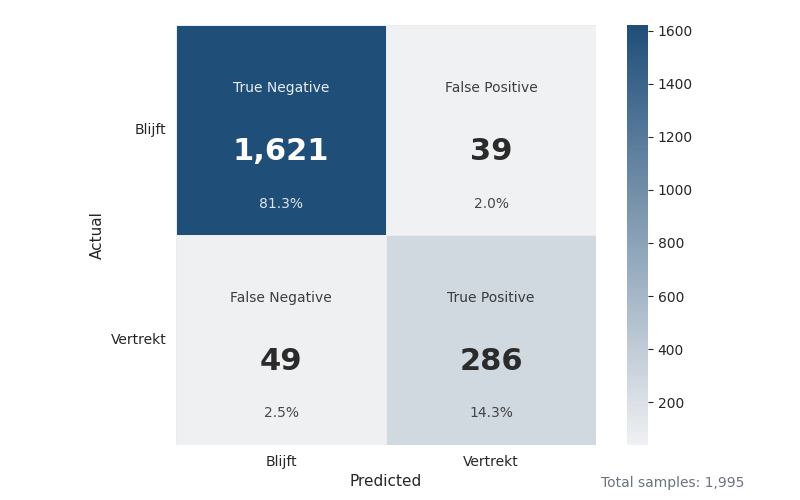

In [41]:
y_pred = gridsearch_knn.predict(X)
display_executive_model_evaluation(y, y_pred, class_names=["Blijft", "Vertrekt"])

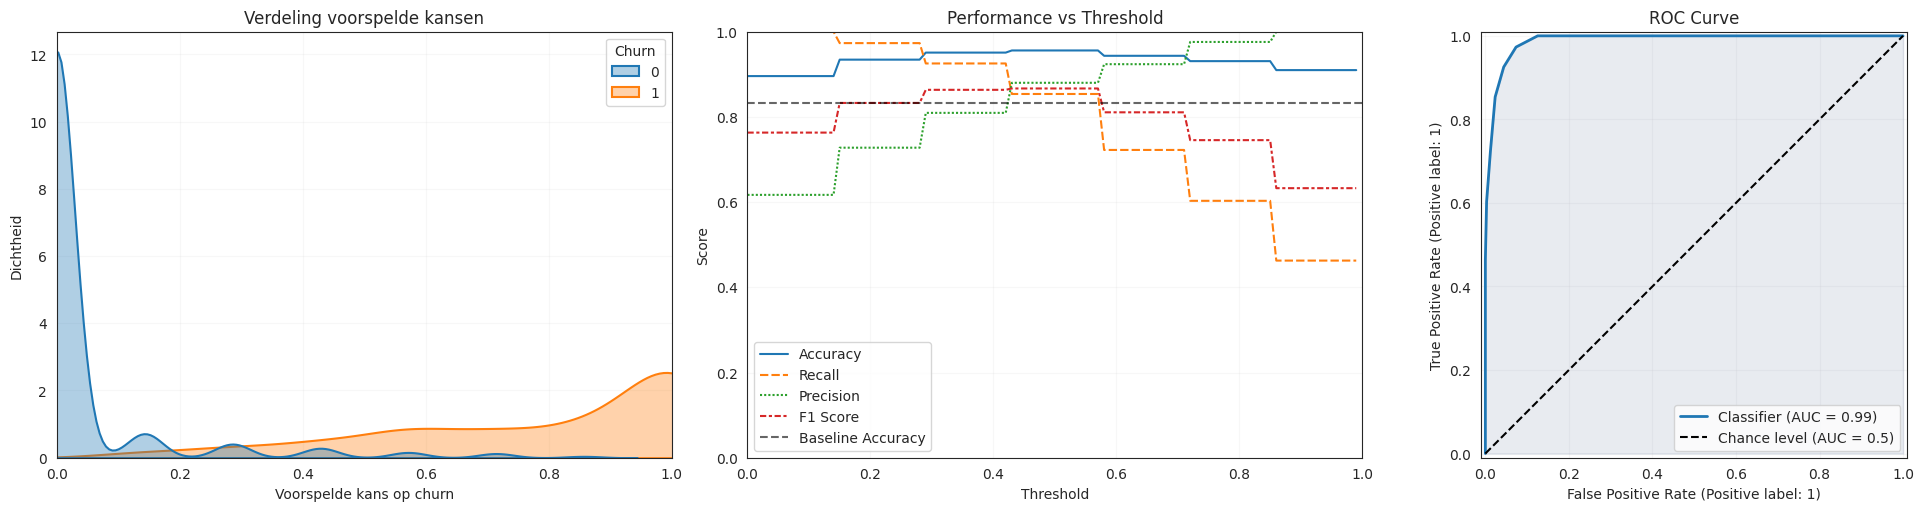

In [42]:
y_prob = gridsearch_knn.predict_proba(X)[:, 1]
evaluate_classification_model(y, y_prob, X, df)

### 7. Model opslaan

De complete pipeline (preprocessing + model) wordt opgeslagen met `joblib.dump()`.
Hiermee kan het model later opnieuw worden geladen zonder hertraining.

In [43]:
joblib.dump(gridsearch_knn.best_estimator_, "knn_model.joblib")
print("Model opgeslagen als knn_model.joblib")

Model opgeslagen als knn_model.joblib


### 8. Beslissingsstrategie & winstanalyse

Voor elke klant berekenen we een **gepersonaliseerde threshold** op basis van verwachte winst bij tarief 1 versus tarief 2.
Klanten waarbij de voorspelde churnkans boven deze threshold uitkomt krijgen tarief 2 aangeboden.

Vervolgens vergelijken we:
- De **modelstrategie** (op basis van voorspelde kansen)
- De **optimale strategie** (op basis van werkelijke churn)

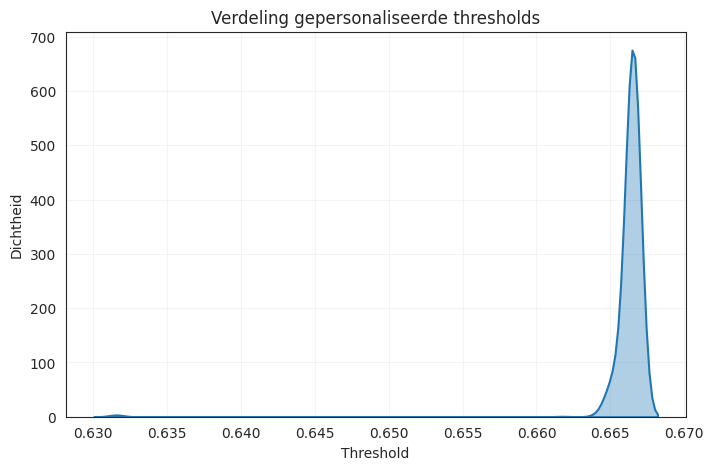

Aantal klanten tarief 2: 222
Totaal aantal klanten: 1995
Percentage tarief 2: 11.13%


In [44]:
y_prob = gridsearch_knn.best_estimator_.predict_proba(X)[:, 1]

W1 = 0.1 * X["Frequency of SMS"] + 0.3 * X["Seconds of Use"]
W2 = 0.07 * X["Frequency of SMS"] + 0.2 * X["Seconds of Use"]

df["thresholds"] = (W1 - W2) / (W1 - 0.75 * W2)

offer_tarief2 = (y_prob >= df["thresholds"])

plt.figure(figsize=(8, 5))
sns.kdeplot(df["thresholds"], fill=True, alpha=0.35, linewidth=1.5)
plt.title("Verdeling gepersonaliseerde thresholds")
plt.xlabel("Threshold")
plt.ylabel("Dichtheid")
plt.grid(alpha=0.2)
plt.show()

n_tarief2 = offer_tarief2.sum()
print(f"Aantal klanten tarief 2: {n_tarief2}")
print(f"Totaal aantal klanten: {len(df)}")
print(f"Percentage tarief 2: {n_tarief2/len(df):.2%}")

In [45]:
sms_pm = X["Frequency of SMS"] / 9
min_pm = (X["Seconds of Use"] / 60) / 9

W1_pm = 0.1 * sms_pm + 0.3 * min_pm
W2_pm = 0.07 * sms_pm + 0.2 * min_pm

E_tarief1_model = (1 - y_prob) * W1_pm
E_tarief2_model = (1 - 0.75 * y_prob) * W2_pm

totale_winst_model = E_tarief2_model[offer_tarief2 == 1].sum() + E_tarief1_model[offer_tarief2 == 0].sum()

E_tarief1_max = (1 - y) * W1_pm
E_tarief2_max = (1 - 0.75 * y) * W2_pm
totale_winst_max = E_tarief2_max[y == 1].sum() + E_tarief1_max[y == 0].sum()

verschil_winst = totale_winst_max - totale_winst_model
n_tarief2_optimaal = y.sum()
verschil_klanten = n_tarief2 - n_tarief2_optimaal
perc_tarief2 = n_tarief2 / len(X)
perc_tarief2_optimaal = n_tarief2_optimaal / len(X)

if verschil_klanten > 0:
    interpretatie = f"Het model biedt {verschil_klanten} klanten te veel tarief 2 aan (te agressief)."
elif verschil_klanten < 0:
    interpretatie = f"Het model biedt {-verschil_klanten} klanten te weinig tarief 2 aan (te voorzichtig)."
else:
    interpretatie = "Het model biedt precies het optimale aantal klanten tarief 2 aan."

interpretatie += f" Het model behaalt {totale_winst_model/totale_winst_max:.2%} van de maximale winst"
interpretatie += f" met een verschil van €{verschil_winst:.2f}."

pct_winst = totale_winst_model / totale_winst_max
bar_len = 30
filled_len = int(bar_len * pct_winst)
bar = '█' * filled_len + '-' * (bar_len - filled_len)

table_md = f"""
### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|------------------------|------------------|
| Optimaal  | {int(n_tarief2_optimaal)} ({perc_tarief2_optimaal:.2%}) | {totale_winst_max:.2f} |
| Model     | {n_tarief2} ({perc_tarief2:.2%}) | {totale_winst_model:.2f} |

**Interpretatie:** {interpretatie}  
**Verschil klanten Tarief 2:** {verschil_klanten:+}  
**Winstverschil:** €{verschil_winst:.2f}  

**Percentage van maximale winst behaald:**  
`{bar}` {pct_winst:.2%}
"""

display(Markdown(table_md))


### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|------------------------|------------------|
| Optimaal  | 335 (16.79%) | 6270.30 |
| Model     | 222 (11.13%) | 6233.45 |

**Interpretatie:** Het model biedt 113 klanten te weinig tarief 2 aan (te voorzichtig). Het model behaalt 99.41% van de maximale winst met een verschil van €36.84.  
**Verschil klanten Tarief 2:** -113  
**Winstverschil:** €36.84  

**Percentage van maximale winst behaald:**  
`█████████████████████████████-` 99.41%
